psi_r:


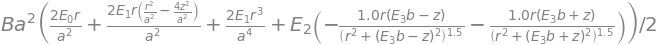

psi_rr:


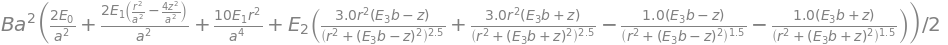

psi_z:


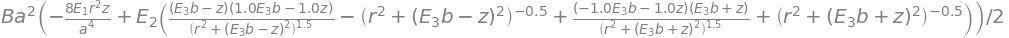

psi_zz:


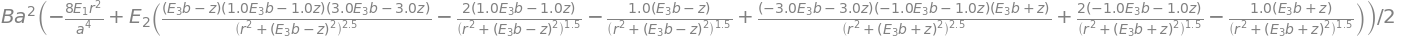

psi_rz:


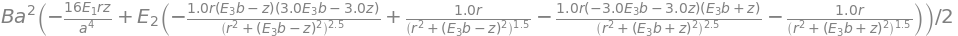

In [1]:
# Curvature Calculations 
# Date: 8.03.26

from sympy.interactive import printing
printing.init_printing(use_latex = True)

import numpy as np
import sympy as sp
from scipy.optimize import root 
import matplotlib.pyplot as plt
import math


def external_E_params(Es, eps, Xs, sig):
    E0, E1, E2, a = Es

    eq1 = E0 - E1 * (4/eps**2) + E2 * (2*eps**2*a/(1-a**2)**2)
    eq2 = E0 + E1 + 2*a*E2 / np.sqrt(eps**2+a**2)
    e0 = eps**2*Xs**3*E2/4/sig**2 
    e1 = (a+sig) / np.sqrt(eps**2 + Xs**2*(a+sig)**2)
    e2 = (a-sig) / np.sqrt(eps**2 + Xs**2*(a-sig)**2)
    e3 = 2*a / np.sqrt(eps**2 + (Xs*a)**2)
    eq3 = E1 - e0 * (e1 + e2 - e3)
    eq4 = E0 + 2*E1/Xs**2 - eps**2*a*Xs**3*E2 / ((a*Xs)**2 + eps**2)**(1.5) - 1

    return [eq1, eq2, eq3, eq4]


Lconv = 1e3
# Variables / Domain Definitions 
Rw          = 6.1/Lconv                     # Wall Radius [m]
Rc          = Rw
zLen        = 200/Lconv                     #liner length [m]

B0  = 30
sig = f = 1.5                                   #flare parameter; adjustable parameter

Rmax        = Rw                        #maximum r-domain value [m]
Rmin        = 0                         #minimum r-domain value [m]
Nr          = 1000                      #number of points in r-direction [\]
dr          = (Rmax - Rmin) / Nr        #radial differential [m]
Zmax        = zLen / 2                  #maximum z-domain value [m]
Zmin        = -zLen / 2                 #minimum z-domain value [m]
Nz          = 1000                      #number of points in z-direction [\]
dz          = (Zmax - Zmin) / Nz        #axial differential [m]
domx        = 1.4                       #domain multiplier to make plotting modifications easier
domy        = 0.8                       #domain multiplier to make plotting modifications easier
Rd          = Rmax * domx               #domain radius [m]
Zd          = Zmax * domy               #domain z-length [m]
r = np.arange(-Rd, Rd+dr, dr)
z = np.arange(-Zd, Zd+dz, dz)    
r_mesh, z_mesh = np.meshgrid(r, z, indexing='ij')

# Define Variables
E0, E1, E2, E3 = sp.symbols("E:4")
B, r, z, a, b = sp.symbols('B r z a b')
psi = sp.symbols('P')

# Define Equations (for Eq. 2)
T1 = E0*(r**2/a**2)
T2 = E1*(r**2/a**2)*(r**2/a**2 - 4*z**2/a**2)
T3 = E2*(((E3*b + z)/((r**2 + (E3*b+z)**2)**0.5))+((E3*b - z)/((r**2 + (E3*b-z)**2)**0.5)))

psi = sp.simplify((B*a**2)/2*(T1+T2+T3))
psi_r = sp.diff(psi, r)
psi_rr = sp.diff(psi_r, r)
psi_z = sp.diff(psi, z)
psi_zz = sp.diff(psi_z, z)
psi_rz = sp.diff(psi_r, z)

print("psi_r:")
display(psi_r)
print("psi_rr:")
display(psi_rr)
print("psi_z:")
display(psi_z)
print("psi_zz:")
display(psi_zz)
print("psi_rz:")
display(psi_rz)
# Define Functions
f_psi = sp.lambdify((B, E0, E1, E2, E3, r, z, a, b), psi)
f_psi_r = sp.lambdify((B, E0, E1, E2, E3, r, z, a, b), psi_r)
f_psi_rr = sp.lambdify((B, E0, E1, E2, E3, r, z, a, b), psi_rr)
f_psi_z = sp.lambdify((B, E0, E1, E2, E3, r, z, a, b), psi_z)
f_psi_zz = sp.lambdify((B, E0, E1, E2, E3, r, z, a, b), psi_zz)
f_psi_rz = sp.lambdify((B, E0, E1, E2, E3, r, z, a, b), psi_rz)

def curvature(B, E0, E1, E2, E3, r, z, a, b):
    num = f_psi_rr(B, E0, E1, E2, E3, r, z, a, b)*(f_psi_z(B, E0, E1, E2, E3, r, z, a, b))**2 - 2*f_psi_rz(B, E0, E1, E2, E3, r, z, a, b)*f_psi_r(B, E0, E1, E2, E3, r, z, a, b)*f_psi_z(B, E0, E1, E2, E3, r, z, a, b) + f_psi_zz(B, E0, E1, E2, E3, r, z, a, b)*(f_psi_r(B, E0, E1, E2, E3, r, z, a, b))**2
    den = ((f_psi_r(B, E0, E1, E2, E3, r, z, a, b))**2 + (f_psi_z(B, E0, E1, E2, E3, r, z, a, b))**2)**(1.5)
    return np.abs(num/den)


# Final Analytical Solution (Eq. 22)
eps = a / b
Xs = a / Rc
T1 = (Xs * B * r**2) / 2
T2 = 1 - (r/a)**2 - (z/b)**4 + f * eps**2
s_psi = np.sqrt(3/2) * T1 * T2     

s_psi_r = sp.diff(s_psi, r)
s_psi_rr = sp.diff(s_psi_r, r)
s_psi_z = sp.diff(s_psi, z)
s_psi_zz = sp.diff(s_psi_z, z)
s_psi_rz = sp.diff(s_psi_r, z)

# Define Functions
fs_psi = sp.lambdify((B, r, z, a, b), s_psi)
fs_psi_r = sp.lambdify((B, r, z, a, b), s_psi_r)
fs_psi_rr = sp.lambdify((B, r, z, a, b), s_psi_rr)
fs_psi_z = sp.lambdify((B, r, z, a, b), s_psi_z)
fs_psi_zz = sp.lambdify((B, r, z, a, b), s_psi_zz)
fs_psi_rz = sp.lambdify((B, r, z, a, b), s_psi_rz)

# curvature based off sporer's function
def s_curvature(B, r, z, a, b):
    num = fs_psi_rr(B, r, z, a, b)*(fs_psi_z(B, r, z, a, b))**2 - 2*fs_psi_rz(B, r, z, a, b)*fs_psi_r(B, r, z, a, b)*fs_psi_z(B, r, z, a, b) + fs_psi_zz(B, r, z, a, b)*(fs_psi_r(B, r, z, a, b))**2
    den = ((fs_psi_r(B, r, z, a, b))**2 + (fs_psi_z(B, r, z, a, b))**2)**(1.5)
    return np.abs(num/den)


def shape_index(a, b, K):
    return (K*b**2)/(a)



In [6]:
### === MAIN
acc = 1000

# Arrays
elong_arr = np.linspace(1,10,num = acc)
Xs_arr = np.linspace(0.3, 0.9,num = acc)
# shape_arr = np.linspace(0, 1, num = acc)

a_arr = Rc*Xs_arr
b_arr =  np.multiply(a_arr, elong_arr)

e_params = []
mask = list(range(0, acc))

# Solving for E_constants for all cases 
for i, E in enumerate(elong_arr):
    initial_guess = [1.0, 0.5, 0.3, 0.2]
    
    result = root(external_E_params, initial_guess, args= (1/E, Xs_arr[i], sig))
    if result.success: 
        E0, E1, E2, E3 = result.x
        e_params.append([E0, E1, E2, E3])
    else: 
        mask.remove(i)

a_arr = a_arr[mask]
b_arr = b_arr[mask]
Xs_arr = Xs_arr[mask]
elong_arr= elong_arr[mask]
eps_lst = 1/elong_arr

curv_arr = []
N_arr = []
Ns_arr = []
mask = []
s_mask = []
for i, E in enumerate(elong_arr):
    Xs = Xs_arr[i]
    Bw = B0/(1-(Xs**2))
    a = a_arr[i]
    b = b_arr[i]
    e0, e1, e2, e3 = e_params[i]

    K = (curvature(Bw, e0, e1, e2, e3, a, 0, a, b))
    if math.isnan(K):
        pass
    else:
        curv_arr.append(K)
        N_arr.append(shape_index(a, b, K))
        mask.append(i)

    k = s_curvature(Bw, a, 0, a, b)
    if math.isnan(k):
        pass
    else:
        Ns_arr.append(shape_index(a, b, k))
        s_mask.append(i)


N_arr = np.array(N_arr)
N_elong_arr = elong_arr[mask]

Ns_elong_arr = elong_arr[s_mask]

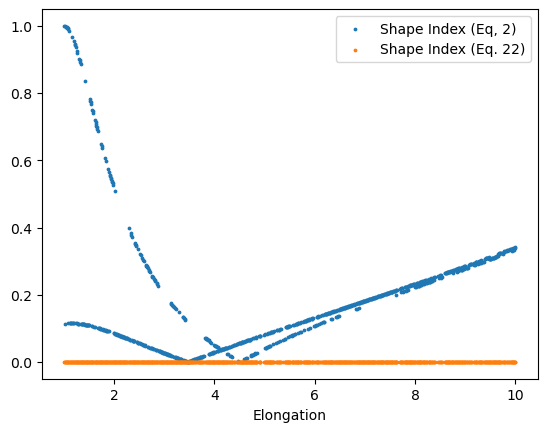

In [7]:
### === PLOTTING 

# Elongation vs Curvature and Shape Index (for r=a, z=0)
fig, ax = plt.subplots()
ax.scatter(N_elong_arr, N_arr, label = "Shape Index (Eq, 2)", s = 3)
ax.scatter(Ns_elong_arr, Ns_arr, label = "Shape Index (Eq. 22)", s = 3)
# ax.scatter(elong_arr, curv_arr, label = "Curvature", s = 3)

ax.set_xlabel("Elongation")
ax.legend()
plt.show()